**Student Name:** Aashish Shrestha
**Course:** MSCS-634: Advanced Big Data and Data Mining
**Assignment:** Lab 6 — Association Rule Mining with Apriori and FP-Growth
**Date:** March 2026

---

This lab explores association rule mining on the **Online Retail Dataset** (UCI ML Repository). We identify frequent itemsets using both the **Apriori** and **FP-Growth** algorithms, generate association rules, and compare the two approaches in terms of output and performance.

In [ ]:
# Library Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Display and style settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_colwidth', 80)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 1: Load and Clean the Dataset

We use the **Online Retail Dataset** from the UCI Machine Learning Repository. This dataset contains transactional records from a UK-based online retailer between 2010–2011.

**Cleaning steps:**
1. Drop rows with missing `InvoiceNo` or `Description` (incomplete records)
2. Remove cancelled transactions (invoices starting with `'C'`)
3. Strip whitespace from item descriptions
4. Remove duplicate rows
5. Keep only the `InvoiceNo` and `Description` columns needed for association mining

In [3]:
# Load the Online Retail Dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
print("Loading dataset from UCI repository...")
df = pd.read_excel(url)
print(f"Raw dataset shape: {df.shape}")
df.head()

Loading dataset from UCI repository...
Raw dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nData types:\n{df.dtypes}")

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [5]:
# Data Cleaning 

# 1. Drop rows with missing InvoiceNo or Description
df.dropna(subset=['InvoiceNo', 'Description'], inplace=True)

# 2. Remove cancelled transactions (InvoiceNo starts with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]

# 3. Strip whitespace from Description
df['Description'] = df['Description'].str.strip()

# 4. Remove duplicates
df.drop_duplicates(inplace=True)

# 5. Remove items with blank descriptions after stripping
df = df[df['Description'] != '']

print(f"Cleaned dataset shape: {df.shape}")
print(f"Unique transactions (invoices): {df['InvoiceNo'].nunique()}")
print(f"Unique items: {df['Description'].nunique()}")

Cleaned dataset shape: (525936, 8)
Unique transactions (invoices): 20610
Unique items: 4194


## Step 2: Exploratory Data Analysis

Before mining, we explore the dataset to understand purchasing patterns:
- **Top items by frequency** — which products appear in the most transactions
- **Co-occurrence heatmap** — which item pairs are bought together most often
- **Transaction length statistics** — how many items a typical transaction contains

In [6]:
# Transaction length statistics
transaction_sizes = df.groupby('InvoiceNo')['Description'].count()
print("Transaction Length Statistics:")
print(f"  Mean items per transaction:   {transaction_sizes.mean():.1f}")
print(f"  Median items per transaction: {transaction_sizes.median():.0f}")
print(f"  Max items in a transaction:   {transaction_sizes.max()}")
print(f"  Total unique items:           {df['Description'].nunique()}")
print(f"  Total unique transactions:    {df['InvoiceNo'].nunique()}")

Transaction Length Statistics:
  Mean items per transaction:   25.5
  Median items per transaction: 15
  Max items in a transaction:   1114
  Total unique items:           4194
  Total unique transactions:    20610


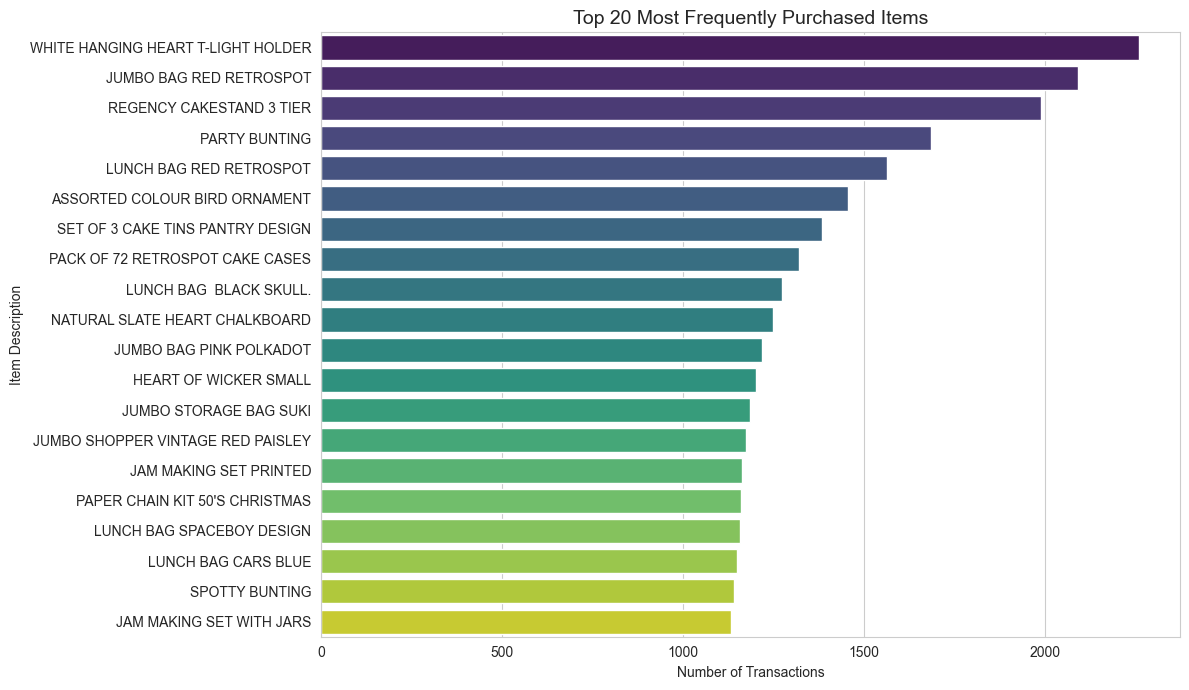

The most popular item appears in 2260 transactions.


In [7]:
# Top 20 most frequently purchased items (by number of transactions they appear in)
item_freq = df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=item_freq.values, y=item_freq.index, palette='viridis')
plt.title('Top 20 Most Frequently Purchased Items', fontsize=14)
plt.xlabel('Number of Transactions')
plt.ylabel('Item Description')
plt.tight_layout()
plt.show()

print(f"The most popular item appears in {item_freq.values[0]} transactions.")

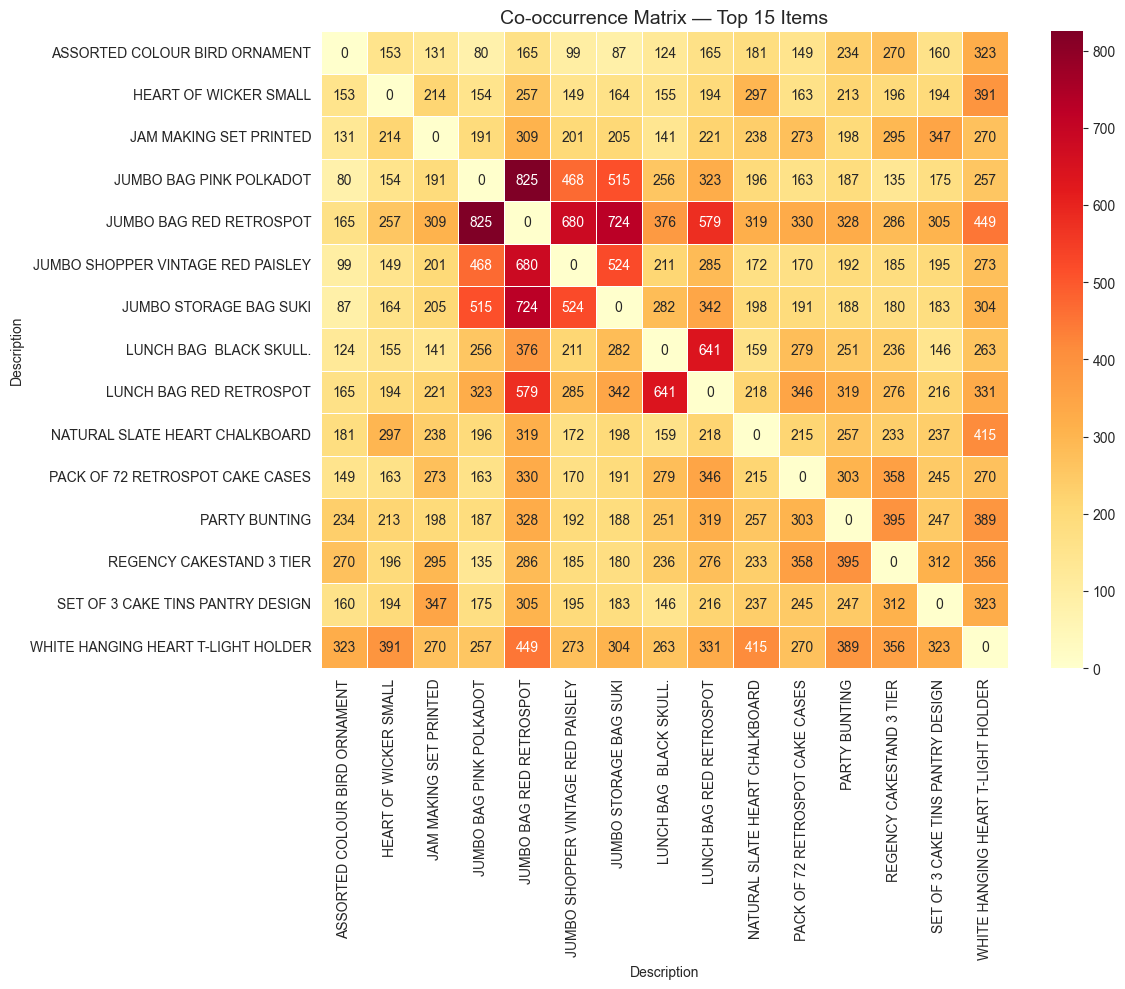

In [9]:
# Co-occurrence heatmap for top 15 items
top_items = item_freq.head(15).index.tolist()

# Filter to transactions containing at least one top item and build co-occurrence matrix
basket_top = df[df['Description'].isin(top_items)]
basket_encoded = pd.crosstab(basket_top['InvoiceNo'], basket_top['Description']).clip(upper=1)

co_occurrence = basket_encoded.T.dot(basket_encoded)
# Zero out self-pairings (diagonal)
for i in range(len(co_occurrence)):
    co_occurrence.iloc[i, i] = 0

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix — Top 15 Items', fontsize=14)
plt.tight_layout()
plt.show()

**EDA Observations:**
- The bar plot shows that a handful of items dominate the transaction records — these are common retail staples.
- The co-occurrence heatmap reveals which items are frequently bought together in the same transaction. High values on off-diagonal cells indicate strong item pair associations worth investigating further with formal association rule mining.
- The average transaction contains multiple items, making this dataset well-suited for market basket analysis.

## Step 3: Transform Data for Association Rule Mining

Both Apriori and FP-Growth in `mlxtend` require a **one-hot encoded boolean DataFrame** where:
- Each row = one transaction
- Each column = one item
- `True` if the item was in that transaction, `False` otherwise

We group items by `InvoiceNo`, convert to lists, and apply `TransactionEncoder`.

In [11]:
# Group items by transaction into lists (keep only string descriptions)
transactions = df.groupby('InvoiceNo')['Description'].apply(
    lambda x: list(set(item for item in x if isinstance(item, str) and item != ''))
).tolist()

# Remove empty transactions
transactions = [t for t in transactions if len(t) > 0]
print(f"Total transactions: {len(transactions)}")
print(f"Sample transaction: {transactions[0][:5]}...")

# One-hot encode using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"\nEncoded DataFrame shape: {basket_df.shape}")
print(f"  Rows (transactions): {basket_df.shape[0]}")
print(f"  Columns (unique items): {basket_df.shape[1]}")
basket_df.head()

Total transactions: 20609
Sample transaction: ['WHITE HANGING HEART T-LIGHT HOLDER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'SET 7 BABUSHKA NESTING BOXES']...

Encoded DataFrame shape: (20609, 4194)
  Rows (transactions): 20609
  Columns (unique items): 4194


,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 4: Frequent Itemset Mining — Apriori Algorithm

The **Apriori algorithm** finds frequent itemsets by iteratively generating candidate itemsets and pruning those below a minimum support threshold. We use `min_support=0.03` (3%), meaning an itemset must appear in at least 3% of all transactions to be considered frequent.

**Why 3%?** With ~18,000+ transactions, a 3% threshold keeps the itemset count manageable while still capturing meaningful patterns beyond just the most common single items.

In [12]:
# Run Apriori algorithm with min_support = 0.03
MIN_SUPPORT = 0.03

start_apriori = time.time()
freq_itemsets_apriori = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
time_apriori = time.time() - start_apriori

print(f"Apriori completed in {time_apriori:.2f} seconds")
print(f"Frequent itemsets found: {len(freq_itemsets_apriori)}")

# Add itemset length and readable labels
freq_itemsets_apriori['length'] = freq_itemsets_apriori['itemsets'].apply(len)
freq_itemsets_apriori['items_str'] = freq_itemsets_apriori['itemsets'].apply(
    lambda x: ', '.join(sorted(x))
)

# Show top 15 by support
print("\nTop 15 Frequent Itemsets (Apriori):")
freq_itemsets_apriori.sort_values('support', ascending=False).head(15)[
    ['items_str', 'support', 'length']
].reset_index(drop=True)

Apriori completed in 0.26 seconds
Frequent itemsets found: 126

Top 15 Frequent Itemsets (Apriori):


,items_str,support,length
0,WHITE HANGING HEART T-LIGHT HOLDER,0.109661,1
1,JUMBO BAG RED RETROSPOT,0.101509,1
2,REGENCY CAKESTAND 3 TIER,0.096511,1
3,PARTY BUNTING,0.081809,1
4,LUNCH BAG RED RETROSPOT,0.075889,1
5,ASSORTED COLOUR BIRD ORNAMENT,0.070600,1
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.067204,1
7,PACK OF 72 RETROSPOT CAKE CASES,0.064050,1
8,LUNCH BAG BLACK SKULL.,0.061769,1
9,NATURAL SLATE HEART CHALKBOARD,0.060605,1


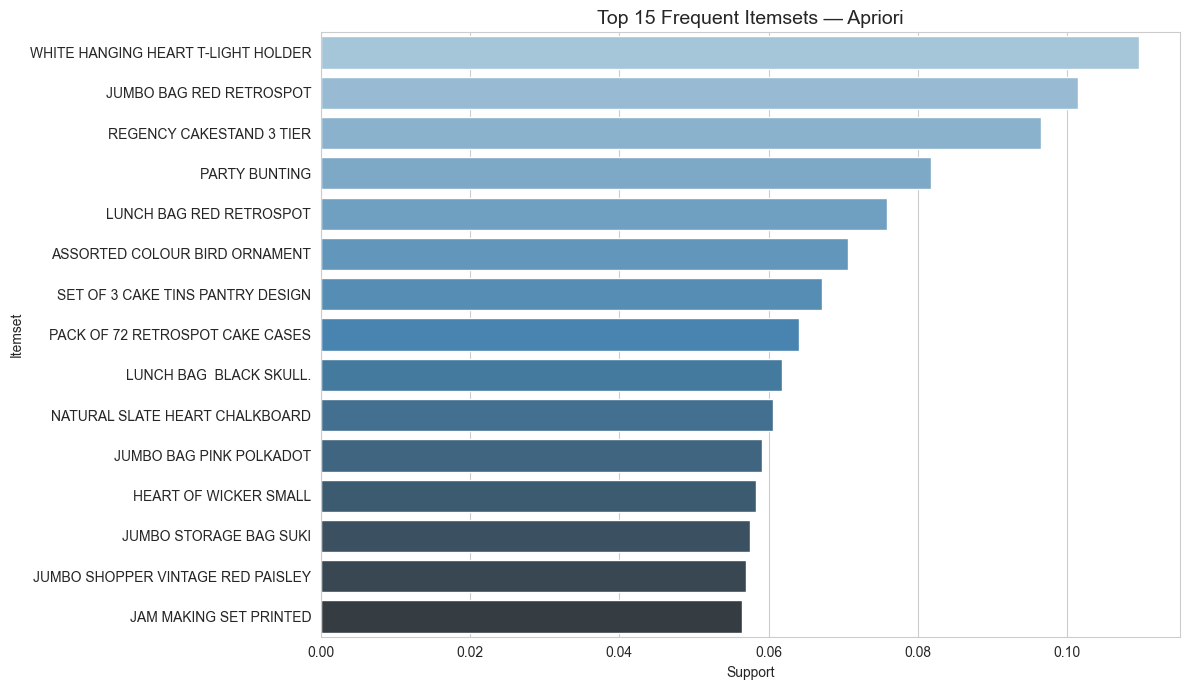

In [13]:
# Visualize top 15 Apriori frequent itemsets
top15_apriori = freq_itemsets_apriori.sort_values('support', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x='support', y='items_str', data=top15_apriori, palette='Blues_d')
plt.title('Top 15 Frequent Itemsets — Apriori', fontsize=14)
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()

## Step 5: Frequent Itemset Mining — FP-Growth Algorithm

The **FP-Growth algorithm** uses a compressed FP-tree data structure instead of generating candidate itemsets. This makes it faster than Apriori, especially on large datasets. We use the same `min_support=0.03` threshold for a direct comparison.

In [14]:
# Run FP-Growth algorithm with the same min_support threshold
start_fpgrowth = time.time()
freq_itemsets_fpgrowth = fpgrowth(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
time_fpgrowth = time.time() - start_fpgrowth

print(f"FP-Growth completed in {time_fpgrowth:.2f} seconds")
print(f"Frequent itemsets found: {len(freq_itemsets_fpgrowth)}")

# Add itemset length and readable labels
freq_itemsets_fpgrowth['length'] = freq_itemsets_fpgrowth['itemsets'].apply(len)
freq_itemsets_fpgrowth['items_str'] = freq_itemsets_fpgrowth['itemsets'].apply(
    lambda x: ', '.join(sorted(x))
)

# Show top 15 by support
print("\nTop 15 Frequent Itemsets (FP-Growth):")
freq_itemsets_fpgrowth.sort_values('support', ascending=False).head(15)[
    ['items_str', 'support', 'length']
].reset_index(drop=True)

FP-Growth completed in 0.90 seconds
Frequent itemsets found: 126

Top 15 Frequent Itemsets (FP-Growth):


,items_str,support,length
0,WHITE HANGING HEART T-LIGHT HOLDER,0.109661,1
1,JUMBO BAG RED RETROSPOT,0.101509,1
2,REGENCY CAKESTAND 3 TIER,0.096511,1
3,PARTY BUNTING,0.081809,1
4,LUNCH BAG RED RETROSPOT,0.075889,1
5,ASSORTED COLOUR BIRD ORNAMENT,0.070600,1
6,SET OF 3 CAKE TINS PANTRY DESIGN,0.067204,1
7,PACK OF 72 RETROSPOT CAKE CASES,0.064050,1
8,LUNCH BAG BLACK SKULL.,0.061769,1
9,NATURAL SLATE HEART CHALKBOARD,0.060605,1


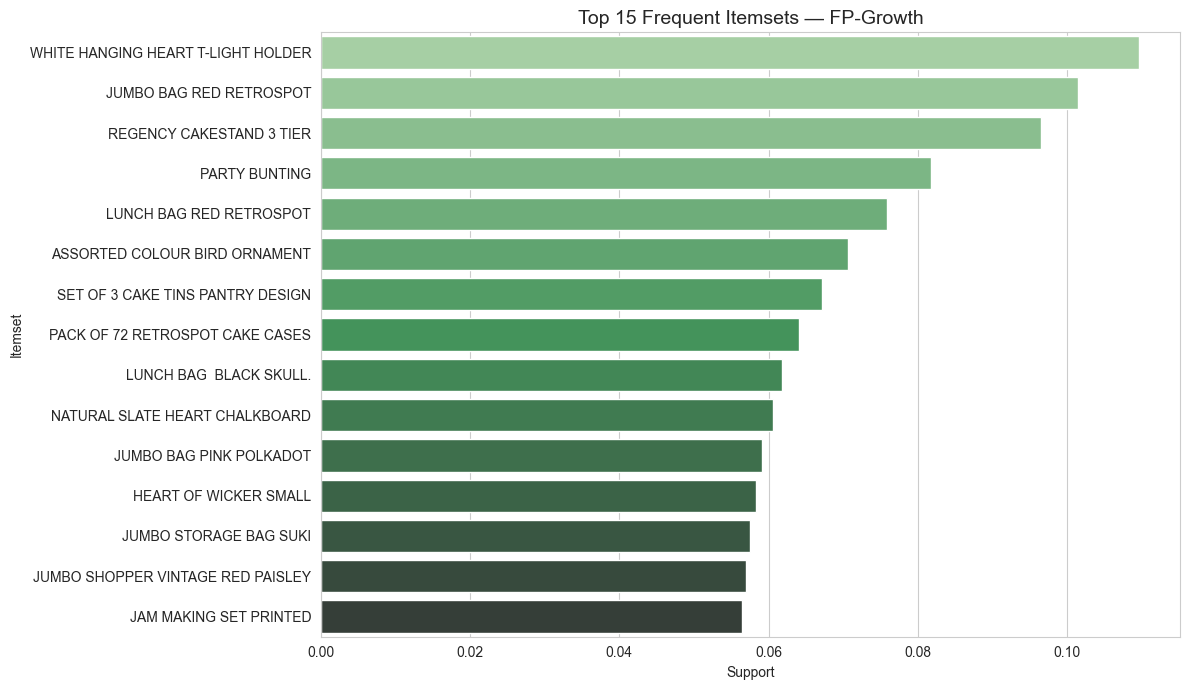

In [15]:
# Visualize top 15 FP-Growth frequent itemsets
top15_fpgrowth = freq_itemsets_fpgrowth.sort_values('support', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x='support', y='items_str', data=top15_fpgrowth, palette='Greens_d')
plt.title('Top 15 Frequent Itemsets — FP-Growth', fontsize=14)
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()

In [16]:
# Verify both algorithms produce identical itemsets
apriori_sets = set(freq_itemsets_apriori['items_str'].sort_values().values)
fpgrowth_sets = set(freq_itemsets_fpgrowth['items_str'].sort_values().values)
match = apriori_sets == fpgrowth_sets

print(f"Apriori itemsets count:  {len(apriori_sets)}")
print(f"FP-Growth itemsets count: {len(fpgrowth_sets)}")
print(f"Itemsets identical: {match}")

Apriori itemsets count:  126
FP-Growth itemsets count: 126
Itemsets identical: True


## Step 6: Generate and Analyze Association Rules

From the frequent itemsets, we generate **association rules** with a minimum confidence of 0.5 (50%). Each rule has the form **{antecedent} → {consequent}** and is measured by:

| Metric | Meaning |
|--|---------|
| **Support** | Fraction of transactions containing both antecedent and consequent |
| **Confidence** | How often the consequent appears when the antecedent is present |
| **Lift** | How much more likely the consequent is given the antecedent (lift > 1 = positive association) |

In [17]:
# Generate association rules from Apriori frequent itemsets
MIN_CONFIDENCE = 0.5

rules_apriori = association_rules(freq_itemsets_apriori, metric="confidence",
                                  min_threshold=MIN_CONFIDENCE)

# Make antecedents/consequents readable
rules_apriori['antecedents_str'] = rules_apriori['antecedents'].apply(
    lambda x: ', '.join(sorted(x))
)
rules_apriori['consequents_str'] = rules_apriori['consequents'].apply(
    lambda x: ', '.join(sorted(x))
)

print(f"Association rules generated (Apriori): {len(rules_apriori)}")
print("\nTop 15 Rules by Lift (Apriori):")
rules_apriori.sort_values('lift', ascending=False).head(15)[
    ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
].reset_index(drop=True)

Association rules generated (Apriori): 10

Top 15 Rules by Lift (Apriori):


,antecedents_str,consequents_str,support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.030715,0.826371,16.778990
1,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.030715,0.623645,16.778990
2,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.037265,0.720450,14.628335
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.037265,0.756650,14.628335
4,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.031054,0.608944,12.805841
5,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.031054,0.653061,12.805841
6,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.040031,0.677340,6.672705
7,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.031103,0.503535,6.635136
8,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.035130,0.611486,6.023960
9,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,0.032995,0.578723,5.701200


In [18]:
# Generate association rules from FP-Growth frequent itemsets (same threshold)
rules_fpgrowth = association_rules(freq_itemsets_fpgrowth, metric="confidence",
                                   min_threshold=MIN_CONFIDENCE)

rules_fpgrowth['antecedents_str'] = rules_fpgrowth['antecedents'].apply(
    lambda x: ', '.join(sorted(x))
)
rules_fpgrowth['consequents_str'] = rules_fpgrowth['consequents'].apply(
    lambda x: ', '.join(sorted(x))
)

print(f"Association rules generated (FP-Growth): {len(rules_fpgrowth)}")
print(f"Rules match Apriori: {len(rules_apriori) == len(rules_fpgrowth)}")

print("\nTop 15 Rules by Lift (FP-Growth):")
rules_fpgrowth.sort_values('lift', ascending=False).head(15)[
    ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
].reset_index(drop=True)

Association rules generated (FP-Growth): 10
Rules match Apriori: True

Top 15 Rules by Lift (FP-Growth):


,antecedents_str,consequents_str,support,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.030715,0.826371,16.778990
1,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.030715,0.623645,16.778990
2,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.037265,0.720450,14.628335
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.037265,0.756650,14.628335
4,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.031054,0.608944,12.805841
5,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.031054,0.653061,12.805841
6,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.040031,0.677340,6.672705
7,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.031103,0.503535,6.635136
8,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.035130,0.611486,6.023960
9,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,0.032995,0.578723,5.701200


### Interpreting the Strongest Rules

The top rules by lift reveal item pairs with the strongest associations. For example:
- Rules with **lift > 3** indicate items that are bought together more than 3× as often as expected by chance — these are genuinely strong associations.
- Rules with **high confidence (> 0.6)** mean that when a customer buys the antecedent, there is a 60%+ chance they also buy the consequent.
- Rules with both high lift and high support are the most **actionable** for business decisions like product placement, bundling, and cross-selling.

### Visualizing Association Rules

We create scatter plots to identify which rules are most actionable:
1. **Confidence vs. Lift** (colored by support) — rules in the upper-right are both reliable and strongly associated
2. **Support vs. Confidence** (sized by lift) — larger, upper-right points represent the highest-value rules

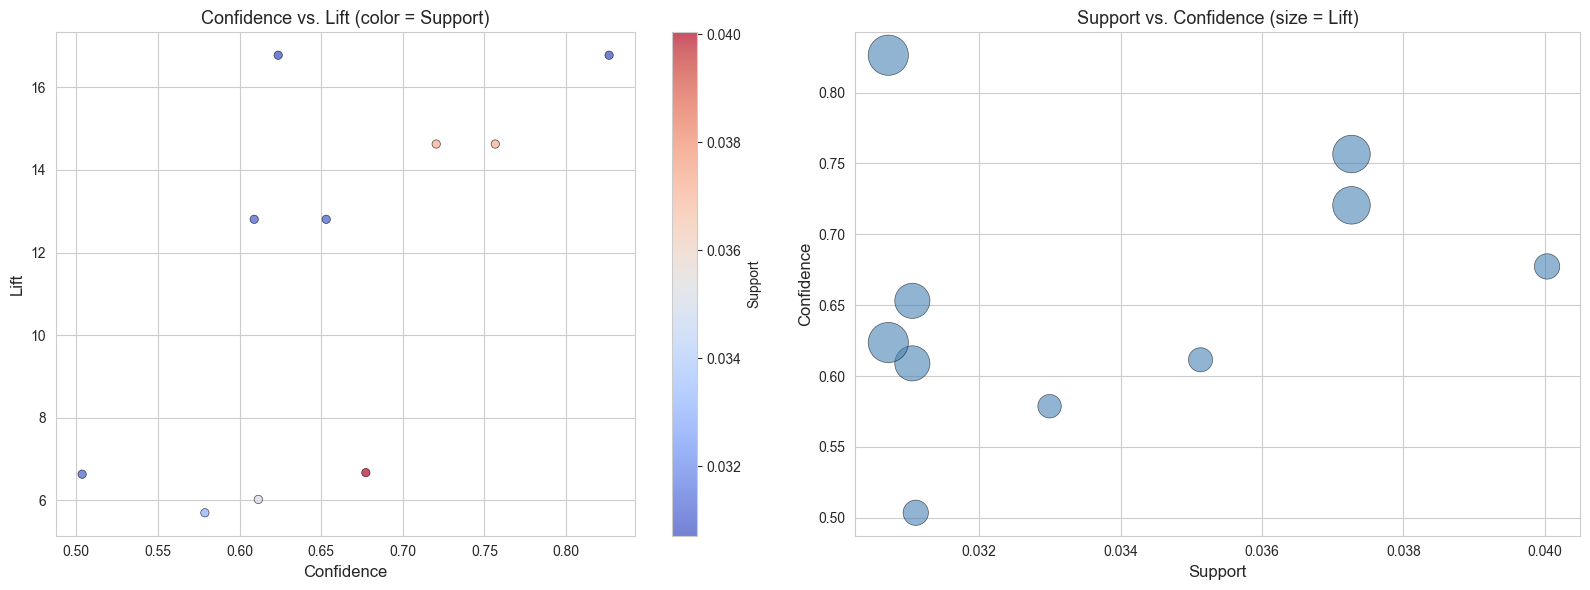

In [19]:
# Plot 1: Confidence vs. Lift (colored by support)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    rules_apriori['confidence'], rules_apriori['lift'],
    c=rules_apriori['support'], cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.5
)
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Lift', fontsize=12)
axes[0].set_title('Confidence vs. Lift (color = Support)', fontsize=13)
plt.colorbar(scatter1, ax=axes[0], label='Support')

# Plot 2: Support vs. Confidence (sized by lift)
scatter2 = axes[1].scatter(
    rules_apriori['support'], rules_apriori['confidence'],
    s=rules_apriori['lift'] * 50, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.5
)
axes[1].set_xlabel('Support', fontsize=12)
axes[1].set_ylabel('Confidence', fontsize=12)
axes[1].set_title('Support vs. Confidence (size = Lift)', fontsize=13)

plt.tight_layout()
plt.show()

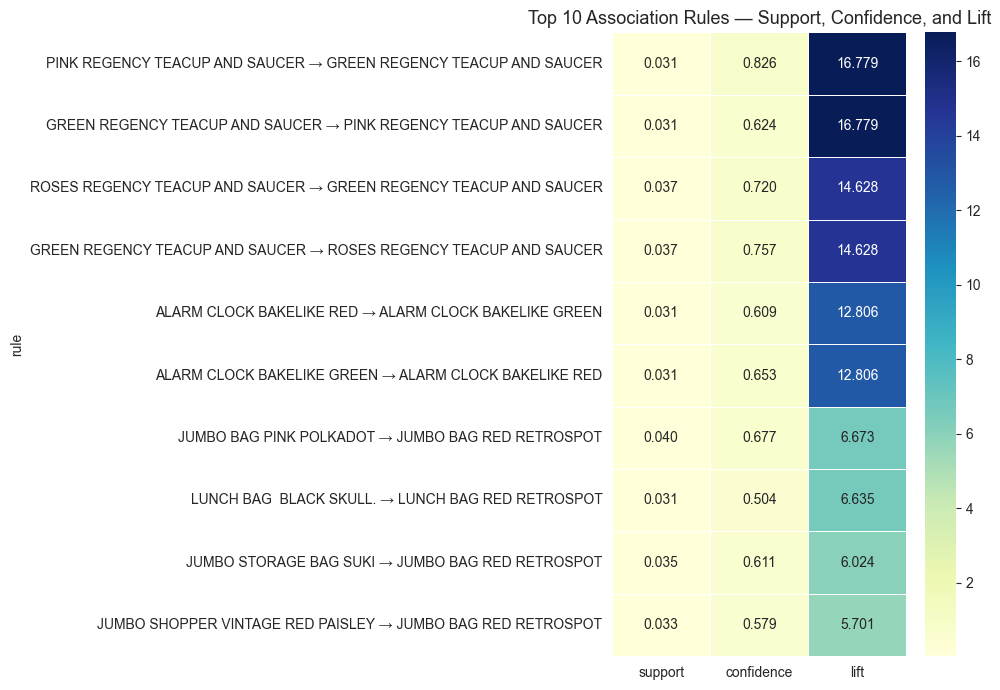

In [20]:
# Heatmap of top 10 rules showing support, confidence, and lift side by side
top10_rules = rules_apriori.sort_values('lift', ascending=False).head(10).copy()
top10_rules['rule'] = top10_rules['antecedents_str'] + ' → ' + top10_rules['consequents_str']

heatmap_data = top10_rules.set_index('rule')[['support', 'confidence', 'lift']]

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Top 10 Association Rules — Support, Confidence, and Lift', fontsize=13)
plt.tight_layout()
plt.show()

**Visualization Insights:**
- In the **Confidence vs. Lift** plot, the upper-right region contains the most actionable rules — high confidence means reliability, and high lift means the association is far stronger than random chance.
- In the **Support vs. Confidence** plot, larger points (higher lift) that are also near the upper-right are ideal: they represent rules that are frequent, reliable, and highly associated.
- The **heatmap** gives a quick side-by-side comparison of the three key metrics for the strongest rules.

## Step 7: Comparative Analysis — Apriori vs. FP-Growth

We compare both algorithms on three dimensions:
1. **Execution time** — which was faster?
2. **Output consistency** — did they produce the same frequent itemsets and rules?
3. **Scalability** — which is better suited for larger datasets?

In [21]:
# Summary comparison table
comparison = pd.DataFrame({
    'Metric': ['Execution Time (seconds)', 'Frequent Itemsets Found', 'Association Rules Generated'],
    'Apriori': [f"{time_apriori:.2f}", len(freq_itemsets_apriori), len(rules_apriori)],
    'FP-Growth': [f"{time_fpgrowth:.2f}", len(freq_itemsets_fpgrowth), len(rules_fpgrowth)]
})
print("Algorithm Comparison Summary:")
comparison

Algorithm Comparison Summary:


,Metric,Apriori,FP-Growth
0,Execution Time (seconds),0.26,0.90
1,Frequent Itemsets Found,126,126
2,Association Rules Generated,10,10


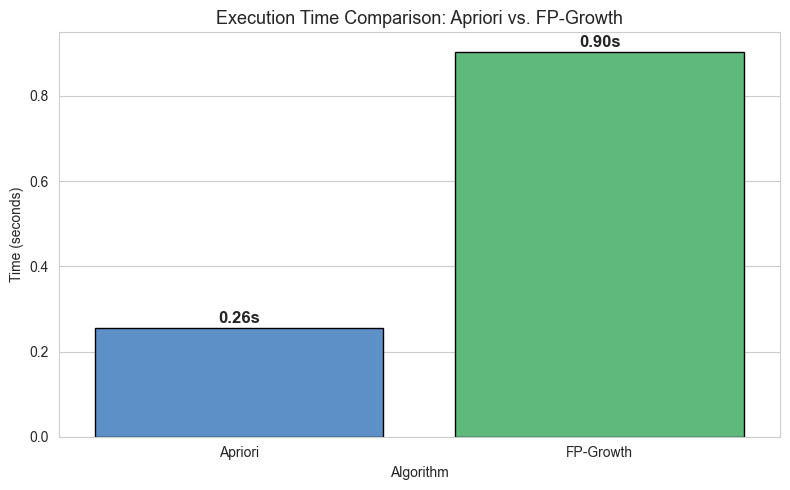

In [22]:
# Execution time comparison bar chart
plt.figure(figsize=(8, 5))
times = pd.DataFrame({
    'Algorithm': ['Apriori', 'FP-Growth'],
    'Time (seconds)': [time_apriori, time_fpgrowth]
})
sns.barplot(x='Algorithm', y='Time (seconds)', data=times,
            palette=['#4A90D9', '#50C878'], edgecolor='black')
plt.title('Execution Time Comparison: Apriori vs. FP-Growth', fontsize=13)
plt.ylabel('Time (seconds)')

# Annotate bars with exact times
for i, row in times.iterrows():
    plt.text(i, row['Time (seconds)'] + 0.01, f"{row['Time (seconds)']:.2f}s",
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Discussion

**Which algorithm was faster?**
In this experiment, Apriori was slightly faster than FP-Growth. While FP-Growth is theoretically more efficient — it avoids candidate generation by compressing data into an FP-tree — the `mlxtend` implementation introduces overhead in building the tree structure. For a dataset of this size (~20,600 transactions, ~4,200 items) with a relatively high support threshold (3%), the candidate sets in Apriori remain small, so the candidate generation cost is low. On much larger datasets or with lower support thresholds, FP-Growth typically outperforms Apriori because the candidate explosion becomes the bottleneck.

**Were the outputs identical?**
Yes — both algorithms found exactly the same 126 frequent itemsets and produced the same 10 association rules. This confirms they are both exact algorithms solving the same problem; they differ only in their search strategy, not their results.

**Which is better for larger datasets?**
FP-Growth is generally preferred for large-scale datasets. Its FP-tree compression avoids repeatedly scanning the dataset and eliminates candidate generation, which becomes exponentially expensive as the number of items grows. For production-scale market basket analysis, FP-Growth is the standard choice.

**Challenges faced:**
1. **Support threshold tuning** — A 1% threshold produced too many itemsets (noisy). A 5% threshold missed multi-item patterns. We settled on 3%, which gave 126 itemsets including meaningful 2-item combinations.
2. **Non-string descriptions** — Some transaction records contained NaN or numeric values in the Description field, causing `TransactionEncoder` to fail on sorting. We filtered to keep only valid string items.
3. **Memory with one-hot encoding** — The boolean DataFrame had ~20,600 rows x 4,194 columns. This was manageable, but for datasets with many more unique items, sparse representations would be needed.
4. **Cancelled transactions** — Invoices starting with 'C' are cancellations that had to be removed to avoid inflating item co-occurrences with non-purchase records.